# Anthropic compute Monte Carlo

Anthropic discloses nothing directly, so we start from one outside anchor: the
leaked OpenAI internal memo, which put Anthropic at about **1.4 GW of compute
online at the end of 2025** (roughly 75% of OpenAI's own 1.9 GW). We treat that
as the *mainline* power figure with a 90% CI of **1.0–1.9 GW** (see §4).

The hard part is turning gigawatts into **H100-equivalents (H100e)**, which
depends on the chip mix. Anthropic's fleet is Trainium2-heavy, with the rest
split between Nvidia (Hopper + Blackwell) and Google TPU. The finding that
simplifies everything: at a fixed power budget the **Nvidia mix and the TPU mix
buy about the same H100e per watt, while Trainium2 buys noticeably less**. So the
fleet collapses to two buckets — high-efficiency non-Trainium (Nvidia or TPU) and
lower-efficiency Trainium2 — and the main lever that moves H100e is the
**Trainium2 share of total power**, which we sweep. Both buckets' efficiencies
also carry sampled multipliers (§3): the non-Trainium one mirrors the
fleet-efficiency uncertainty the OpenAI model samples, and the Trainium2 one
covers its estimated TDP and Nvidia-derived power overhead.

Unlike the OpenAI power model, there is no deployment-lag machinery here: the
memo's 1.4 GW is described as already *online*, and the mix is specified
directly rather than inferred from a vendor's shipment history.

In [1]:
import contextlib
import io
import runpy
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import squigglepy as sq

# Shared modules (lab_compute_utils, epoch_data) live at the repo root, one
# level up from notebooks/.
sys.path.insert(0, str(Path('..').resolve()))

N_SAMPLES = 5000
sq.set_seed(42)  # squigglepy has its own RNG; np.random.seed does not affect it

CHIPS = ['H100', 'GB200', 'Trainium2']
CHIP_COLORS = {'H100': '#76b900', 'GB200': '#1a73e8', 'Trainium2': '#e8710a'}


def fmt(value):
    """Format an H100e or chip count as a short string (millions or thousands)."""
    if abs(value) >= 1e6:
        return f'{value / 1e6:.2f}M'
    return f'{value / 1e3:,.0f}k'


def percentiles(samples):
    """Return (5th, 50th, 95th) percentiles of a sample array."""
    p = sq.get_percentiles(samples, percentiles=[5, 50, 95])
    return p[5], p[50], p[95]

## Canonical parameters

The sampled priors are loaded from `lab_model_params.csv` — the single source
of truth shared with the other lab notebooks and `frontier_lab_compute_model.py`.
Edit the sheet (leaving a note in its description column) to change a prior.
The sheet's `chip_specs` rows supply the shared hardware constants used below:
TPU TDPs, the IT-power overhead, and the Trainium2 power equivalency.

In [2]:
from lab_compute_utils import load_lab_params, lab_params_table
from epoch_data import load_chip_sales_cumulative

LAB_PARAMS = load_lab_params()
PARAMS = LAB_PARAMS['anthropic']
CHIP_SPECS = LAB_PARAMS['chip_specs']
lab_params_table('anthropic')

,param,dist,low,high,lclip,rclip,units,description,last_updated
0,lab_power_gw,to,1.00,1.90,NaN,NaN,GW,"End-2025 IT power, 90% CI 1.0-1.9 GW (geomean ...",7/30/26
1,trainium_share,norm,0.35,0.70,0.1,0.9,share,"Trainium2 share of end-2025 IT power, anchored...",7/3/26
2,nontrainium_eff,to,0.80,1.25,NaN,NaN,multiplier,Sampled efficiency multiplier on the non-Train...,8/4/26
3,trainium_eff,to,0.85,1.20,NaN,NaN,multiplier,Sampled efficiency multiplier on the Trainium2...,8/4/26
4,cloud_spend_2024,to,2.00,3.00,NaN,NaN,USD B,Anthropic's 2024 full-year cloud compute spend...,7/30/26
5,cloud_spend_2025,to,5.50,8.40,NaN,NaN,USD B,Anthropic's 2025 full-year cloud compute spend...,7/30/26
6,spend_growth_shape_2025,to,0.90,1.50,NaN,NaN,multiplier,Within-2025 spend growth as a multiple of the ...,7/30/26
7,effective_price_2024,to,1.50,2.50,NaN,NaN,USD/H100e-hr,Anthropic's effective 2024 price per H100e-hou...,7/30/26


## 1. Borrow the Nvidia specs and the H100:GB200 ratio from the OpenAI model

Two things come straight from `openai_power_model.py` so the two
notebooks stay consistent:

- **Per-chip specs** for the Nvidia parts — IT watts per GPU and H100e per GPU.
- **OpenAI's end-2025 H100:GB200 ratio.** OpenAI's fleet also carries trace
  A100 and some GB300; we drop the A100 and fold GB300 into the Blackwell
  bucket, leaving a clean "Hopper vs Blackwell" split that we relabel
  H100 vs GB200 for Anthropic.

We run the OpenAI script once, quietly (its prints and charts suppressed), and
read the numbers out of its namespace.

In [3]:
def load_openai_namespace():
    """Execute the OpenAI notebook script and hand back its variables, without
    letting its own prints or charts render here."""
    oai_path = 'openai_power_model.py'
    original_show = plt.show
    plt.show = lambda *args, **kwargs: None  # swallow the OpenAI figures
    try:
        with contextlib.redirect_stdout(io.StringIO()), warnings.catch_warnings():
            warnings.simplefilter('ignore')
            namespace = runpy.run_path(oai_path)
    finally:
        plt.show = original_show
        plt.close('all')
    return namespace


openai = load_openai_namespace()
openai_last_date = openai['last_date']
openai_counts = openai['mc'][openai_last_date]['counts']

# OpenAI's per-chip specs (the model calls Blackwell "B200").
oai_watts = openai['watts_per_gpu']
oai_h100e = openai['h100e_per_gpu']

# OpenAI's end-2025 Hopper vs Blackwell chip counts (median across its Monte
# Carlo), A100 dropped. This ratio is what we borrow for Anthropic's Nvidia mix.
hopper_units = float(np.median(openai_counts['H100/H200']))
blackwell_units = float(np.median(openai_counts['B200'] + openai_counts['B300']))
openai_h100_count_fraction = hopper_units / (hopper_units + blackwell_units)

print(f'Borrowed from OpenAI ({openai_last_date.strftime("%Y")} fleet, A100 dropped):')
print(f'   H100  : IT power {oai_watts["H100/H200"]:,.0f} W/GPU, {oai_h100e["H100/H200"]:.3f} H100e/GPU')
print(f'   GB200 : IT power {oai_watts["B200"]:,.0f} W/GPU, {oai_h100e["B200"]:.3f} H100e/GPU')
print(f'   Hopper : Blackwell count ratio = {hopper_units / blackwell_units:.2f} : 1 '
      f'(H100 = {openai_h100_count_fraction:.0%} of Nvidia chips)')

Borrowed from OpenAI (2025 fleet, A100 dropped):
   H100  : IT power 1,453 W/GPU, 1.000 H100e/GPU
   GB200 : IT power 2,090 W/GPU, 2.527 H100e/GPU
   Hopper : Blackwell count ratio = 1.48 : 1 (H100 = 60% of Nvidia chips)


## 2. Chip specs, including Trainium2

The Nvidia specs are the borrowed ones. Trainium2 needs its own two numbers:

- **H100e per chip.** Trainium2's dense 8-bit throughput is 1299 TFLOP/s; an
  H100's is 1979, so one Trainium2 is about two-thirds of an H100e — the same
  ratio Epoch's chip database reports.
- **IT power per chip.** We pin this to a mid-2025 snapshot of Project Rainier in
  [Epoch's AI data-center directory](https://epoch.ai/data/ai-data-centers/directory/anthropic-amazon-new-carlisle)
  (Anthropic–Amazon New Carlisle): a Trainium2 fleet worth **300k H100-eq draws
  398 MW of IT power**, stored as two `chip_specs` rows in the params sheet.
  Dividing through by the per-chip H100e gives the server-level watts per chip —
  about **871 W**. A watt of Trainium2 then buys marginally *more* H100e than a
  watt of H100 (~754 per MW against ~720) but well under the Blackwell-heavy
  Nvidia and TPU mixes (§3), so Anthropic's fleet still comes out less
  power-efficient per gigawatt than OpenAI's.

In [4]:
TRAINIUM2_H100E = 1299 / 1979      # dense 8-bit throughput relative to an H100

# IT power per chip is pinned to the supplied fleet-level equivalency from the
# params sheet (a Trainium2 fleet worth a known H100e draws a known IT power).
# With the per-chip H100e above, that fixes both the watts per chip and the
# H100e bought per megawatt of Trainium power.
TRAINIUM2_REF_H100E = CHIP_SPECS['trainium2_ref_h100e']
TRAINIUM2_REF_IT_MW = CHIP_SPECS['trainium2_ref_it_mw']
TRAINIUM2_IT_WATTS = TRAINIUM2_H100E / (TRAINIUM2_REF_H100E / TRAINIUM2_REF_IT_MW) * 1e6

WATTS = {
    'H100': oai_watts['H100/H200'],
    'GB200': oai_watts['B200'],
    'Trainium2': TRAINIUM2_IT_WATTS,
}
H100E_PER_CHIP = {
    'H100': oai_h100e['H100/H200'],
    'GB200': oai_h100e['B200'],
    'Trainium2': TRAINIUM2_H100E,
}

print(f'Trainium2: {TRAINIUM2_H100E:.3f} H100e/chip; IT power per chip implied by the '
      f'{TRAINIUM2_REF_H100E / 1e3:.0f}k-H100e = {TRAINIUM2_REF_IT_MW:.0f}-MW equivalency '
      f'= {TRAINIUM2_IT_WATTS:,.0f} W')
lab_params_table('chip_specs')

Trainium2: 0.656 H100e/chip; IT power per chip implied by the 300k-H100e = 398-MW equivalency = 871 W


,param,dist,low,high,lclip,rclip,units,description,last_updated
0,tpu_v5e_tdp,const,225.000,NaN,NaN,NaN,W,TPU v5e chip TDP; per-chip IT power = TDP x tp...,7/3/26
1,tpu_v5p_tdp,const,540.000,NaN,NaN,NaN,W,TPU v5p chip TDP; per-chip IT power = TDP x tp...,7/3/26
2,tpu_v6e_tdp,const,380.000,NaN,NaN,NaN,W,TPU v6e (Trillium) chip TDP; per-chip IT power...,7/3/26
3,tpu_v7_tdp,const,960.000,NaN,NaN,NaN,W,TPU v7 (Ironwood) chip TDP; per-chip IT power ...,7/3/26
4,tpu_it_overhead,const,1.742,NaN,NaN,NaN,ratio,Server-level IT power per chip divided by chip...,7/3/26
5,trainium2_ref_h100e,const,300000.000,NaN,NaN,NaN,H100e,Project Rainier equivalency (New Carlisle mid-...,7/3/26
6,trainium2_ref_it_mw,const,398.000,NaN,NaN,NaN,MW,Project Rainier equivalency (New Carlisle mid-...,7/3/26
7,nvidia_it_overhead,to,0.963,1.3495,1.0,NaN,ratio,IT equipment power divided by GPU-server power...,7/8/26


## 3. Chip efficiency: Nvidia ≈ TPU, Trainium2 lower

At a fixed power budget, the only thing that matters is how much H100e a watt of
IT power buys. We compare three buckets on that metric:

- **Nvidia mix** — H100 + GB200 in OpenAI's borrowed ratio.
- **TPU mix** — Google's actual v5+ fleet from the AI Chip Sales model
  (`tpu_cumulative_by_chip.csv`), each generation weighted by chip count × IT
  power (the OpenAI methodology). TPUs are scored on **native 8-bit peak**,
  consistent with the rest of our work — this flatters the pre-v7 parts that lack
  native FP8, but keeps H100e defined the same way as for the Nvidia chips. TPU
  IT power is TDP × an overhead factor implied by Nvidia's GB200 NVL72 (TDPs
  and the overhead are `chip_specs` rows in the params sheet).
- **Trainium2** — pinned to the 300k-H100e = 398-MW New Carlisle equivalency.

The Nvidia and TPU mixes come out within a few percent of each other; Trainium2
is about 0.75× both.

In [5]:
IT_OVERHEAD = CHIP_SPECS['tpu_it_overhead']  # IT power per chip / TDP, for TPUs (no public server specs)
H100_FLOPS = 1.979e15  # H100 dense 8-bit FLOP/s, the H100e denominator

# Per-chip H100e per MW for the three modelled chips (from the section-2 specs).
h100e_per_mw = {chip: H100E_PER_CHIP[chip] / WATTS[chip] * 1e6 for chip in CHIPS}

# Nvidia mix: H100 + GB200 in OpenAI's count ratio. A chip type's share of the
# power is its share of the chips, weighted by how many watts each chip draws.
h100_units_per_gb200 = openai_h100_count_fraction / (1 - openai_h100_count_fraction)
h100_power_share = (h100_units_per_gb200 * WATTS['H100']) / (
    h100_units_per_gb200 * WATTS['H100'] + WATTS['GB200'])
nvidia_mix_per_mw = h100_power_share * h100e_per_mw['H100'] + (1 - h100_power_share) * h100e_per_mw['GB200']

# TPU mix: Google's real v5+ fleet, scored on native 8-bit peak. TDPs come from
# the params sheet.
tpu_tdp_w = {
    'TPU v5e': CHIP_SPECS['tpu_v5e_tdp'],
    'TPU v5p': CHIP_SPECS['tpu_v5p_tdp'],
    'TPU v6e': CHIP_SPECS['tpu_v6e_tdp'],
    'TPU v7': CHIP_SPECS['tpu_v7_tdp'],
}
tpu_native_8bit_flops = {'TPU v5e': 3.93e14, 'TPU v5p': 9.18e14, 'TPU v6e': 1.836e15, 'TPU v7': 4.614e15}
tpu_it_watts = {chip: tpu_tdp_w[chip] * IT_OVERHEAD for chip in tpu_tdp_w}
tpu_h100e_per_chip = {chip: tpu_native_8bit_flops[chip] / H100_FLOPS for chip in tpu_tdp_w}

tpu_cumulative = load_chip_sales_cumulative('Google')
tpu_snapshot = tpu_cumulative[tpu_cumulative['End date'] == pd.Timestamp('2025-12-31')]
tpu_units = {chip: float(tpu_snapshot.loc[tpu_snapshot['Chip type'] == chip, 'Number of units (median)'].iloc[0])
             for chip in tpu_tdp_w}
tpu_total_it_mw = sum(tpu_units[c] * tpu_it_watts[c] / 1e6 for c in tpu_tdp_w)
tpu_mix_per_mw = sum(tpu_units[c] * tpu_h100e_per_chip[c] for c in tpu_tdp_w) / tpu_total_it_mw

print('Efficiency by bucket (H100e per MW of IT power):')
print(f'   Nvidia mix : {nvidia_mix_per_mw:,.0f}')
print(f'   TPU mix    : {tpu_mix_per_mw:,.0f}   ({tpu_mix_per_mw / nvidia_mix_per_mw:.2f}x the Nvidia mix)')
print(f'   Trainium2  : {h100e_per_mw["Trainium2"]:,.0f}   '
      f'({h100e_per_mw["Trainium2"] / nvidia_mix_per_mw:.2f}x the Nvidia mix)')

Efficiency by bucket (H100e per MW of IT power):
   Nvidia mix : 945
   TPU mix    : 1,009   (1.07x the Nvidia mix)
   Trainium2  : 754   (0.80x the Nvidia mix)


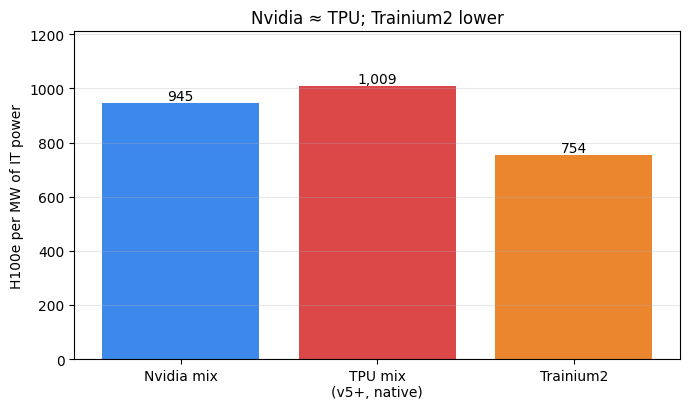

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.2))
buckets = {'Nvidia mix': nvidia_mix_per_mw, 'TPU mix\n(v5+, native)': tpu_mix_per_mw,
           'Trainium2': h100e_per_mw['Trainium2']}
ax.bar(list(buckets), list(buckets.values()), color=['#1a73e8', '#d62728', '#e8710a'], alpha=0.85)
for col, value in enumerate(buckets.values()):
    ax.text(col, value + 12, f'{value:,.0f}', ha='center', fontsize=10)
ax.set_ylabel('H100e per MW of IT power')
ax.set_title('Nvidia ≈ TPU; Trainium2 lower', fontsize=12)
ax.set_ylim(0, max(buckets.values()) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Because the Nvidia and TPU mixes are so close, we treat all non-Trainium compute
as one high-efficiency bucket (their midpoint — the exact Nvidia:TPU split barely
matters) and let Trainium2 keep its 300k = 398 MW value.

The bucket's efficiency itself is uncertain, though: the numbers above are
borrowed point values, while the OpenAI model samples the same quantities (its
deployment lag and server-to-IT overhead put OpenAI's realized H100e per MW at
roughly 0.83×–1.16× of the median). Anthropic's version of that uncertainty
should be at least as wide — the TPU side adds TDP-derived IT power with a
constant overhead and a generation mix read off sales data. So §5 multiplies the
bucket by a sampled efficiency factor, 90% CI **0.8–1.25** (`nontrainium_eff` in
the params sheet; geomean 1.0, so the median is untouched).

The Trainium2 bucket gets the same treatment. Its 300k = 398 MW equivalency is
not an independent site measurement: Epoch's Frontier Data Centers methodology
builds it as ~500 W TDP (a SemiAnalysis estimate — AWS publishes no TDP) times a
1.74× combined server+IT overhead **borrowed from the Nvidia GB200 NVL72
reference design**, i.e. ~870 W per chip. SemiAnalysis's own rack estimates
imply 750–845 W all-in (overhead 1.5–1.69×), so the point value sits at the
power-hungry end of the plausible range. `trainium_eff`, 90% CI **0.85–1.2**
(geomean ~1.01), collapses the TDP and overhead uncertainty into one multiplier.

In [7]:
nontrainium_per_mw = (nvidia_mix_per_mw + tpu_mix_per_mw) / 2
trainium2_per_mw = h100e_per_mw['Trainium2']
print(f'non-Trainium bucket (Nvidia ≈ TPU): {nontrainium_per_mw:,.0f} H100e/MW')
print(f'Trainium2:                          {trainium2_per_mw:,.0f} H100e/MW')

non-Trainium bucket (Nvidia ≈ TPU): 977 H100e/MW
Trainium2:                          754 H100e/MW


## 4. Total power: the OpenAI memo's 1.4 GW

The 1.4 GW figure comes from an OpenAI internal memo that was confident its own
**1.9 GW** exceeded Anthropic's capacity. The 90% CI is **1.0–1.9 GW**, whose
geometric mean (~1.38) keeps the lognormal's median essentially on the memo's
**1.4 GW**.

An earlier revision capped the top end at 1.8 GW — just under OpenAI's 1.9,
since Anthropic is unlikely to be higher if OpenAI believed it was ahead. That
cap was dropped (7/30): OpenAI's 1.9 GW is itself uncertain in our own OpenAI
model (definition, accuracy, rounding), so "Anthropic at 1.9" is compatible
with OpenAI staying ahead — that world simply implies an even larger OpenAI.
The implied correlation between the two labs' power draws is not modeled
directly. The lower end drops to 1.0 GW, which also covers most of the risk
that the 1.4 GW was *facility* rather than IT power (~30% lower, ~1.0 GW).

In [8]:
# 90% CI 1.0-1.9 GW; the geometric mean of the bounds (~1.38) keeps the
# lognormal median essentially on the memo's 1.4 GW.
lab_power_gw = PARAMS['lab_power_gw']  # 90% CI 1.0–1.9 GW, median ~1.38
power_samples_mw = (lab_power_gw @ N_SAMPLES) * 1000.0

lo, mid, hi = percentiles(power_samples_mw)
print(f'Anthropic end-2025 IT power (GW): {lo / 1000:.2f} / {mid / 1000:.2f} / {hi / 1000:.2f}  (5th / median / 95th)')

Anthropic end-2025 IT power (GW): 0.99 / 1.38 / 1.92  (5th / median / 95th)


## 5. The Trainium2 share, anchored on the site power evidence

Instead of sweeping the Trainium2 share, we put a prior on it, anchored on the
Trainium2 campuses tracked in
[Epoch's AI data-center directory](https://epoch.ai/data/ai-data-centers/directory/anthropic-amazon-new-carlisle):

- **New Carlisle (Project Rainier)** stepped up to **~626 MW of IT power in late
  December 2025** on Epoch's dating. The year-end figure is probably ~600 MW, but
  could still have been ~400 MW if that last step in fact landed after year-end.
- **The Amazon Madison campus (Mississippi)** held **~284 MW** from mid-2025
  (Trainium2, by its compute-to-power ratio) — though it is not clear all of it
  served Anthropic.
- Together that is **up to ~900 MW**, and residual Trainium2 beyond the two
  sites plausibly brings the high case to **~1.0 GW ≈ 70%** of the central
  1.4 GW. A share much above that is also hard to square with priors, since
  Anthropic demonstrably runs meaningful Nvidia and TPU fleets too.
- The low case — New Carlisle still at ~400 MW and Madison only partly
  Anthropic's — lands near **~500 MW ≈ 35%**.

So we model the share as roughly **normal with a 90% CI of 0.35–0.70** (median
~0.52), clipped to a sane band. Amazon's **~1.4M deployed Trainium2** ("fully
subscribed") remains a hard ceiling on the implied chip count — Anthropic is the
dominant but not sole customer — and §6 checks the prior against it. Share and
power are sampled independently (scale and mix are largely separate questions).

In [9]:
def anthropic_h100e(total_power_mw, trainium_share, nontrainium_eff=1.0, trainium_eff=1.0):
    """Total H100e for a power draw, a Trainium2 power share, and efficiency
    multipliers on the two buckets (any may be an array of samples; the others
    broadcast). The multipliers default to their medians, ~1.0."""
    blended_per_mw = (trainium_share * trainium2_per_mw * trainium_eff
                      + (1 - trainium_share) * nontrainium_per_mw * nontrainium_eff)
    return total_power_mw * blended_per_mw


# Prior on the Trainium2 share of IT power (clipped to a sane band).
trainium_share_prior = PARAMS['trainium_share']
trainium_share = trainium_share_prior @ N_SAMPLES

# Efficiency multiplier on the non-Trainium bucket (§3): restores the
# fleet-efficiency uncertainty the point specs strip out.
nontrainium_eff = PARAMS['nontrainium_eff'] @ N_SAMPLES

# Efficiency multiplier on the Trainium2 bucket (§3): its ~870 W per chip is an
# estimated TDP times an Nvidia-derived overhead, both uncertain.
trainium_eff = PARAMS['trainium_eff'] @ N_SAMPLES

# Headline Monte Carlo: power, share, and both bucket efficiencies vary together.
anthropic_h100e_samples = anthropic_h100e(power_samples_mw, trainium_share,
                                          nontrainium_eff, trainium_eff)

s_lo, s_mid, s_hi = percentiles(trainium_share)
e_lo, e_mid, e_hi = percentiles(nontrainium_eff)
t_lo, t_mid, t_hi = percentiles(trainium_eff)
h_lo, h_mid, h_hi = percentiles(anthropic_h100e_samples)
print(f'Trainium2 share prior (5th / median / 95th): {s_lo:.0%} / {s_mid:.0%} / {s_hi:.0%}')
print(f'non-Trainium efficiency multiplier (5th / median / 95th): {e_lo:.2f} / {e_mid:.2f} / {e_hi:.2f}')
print(f'Trainium2 efficiency multiplier (5th / median / 95th): {t_lo:.2f} / {t_mid:.2f} / {t_hi:.2f}')
print(f'Anthropic end-2025 H100e (5th / median / 95th): {fmt(h_lo)} / {fmt(h_mid)} / {fmt(h_hi)}')

Trainium2 share prior (5th / median / 95th): 35% / 52% / 70%
non-Trainium efficiency multiplier (5th / median / 95th): 0.79 / 1.00 / 1.24
Trainium2 efficiency multiplier (5th / median / 95th): 0.85 / 1.01 / 1.20
Anthropic end-2025 H100e (5th / median / 95th): 828k / 1.20M / 1.72M


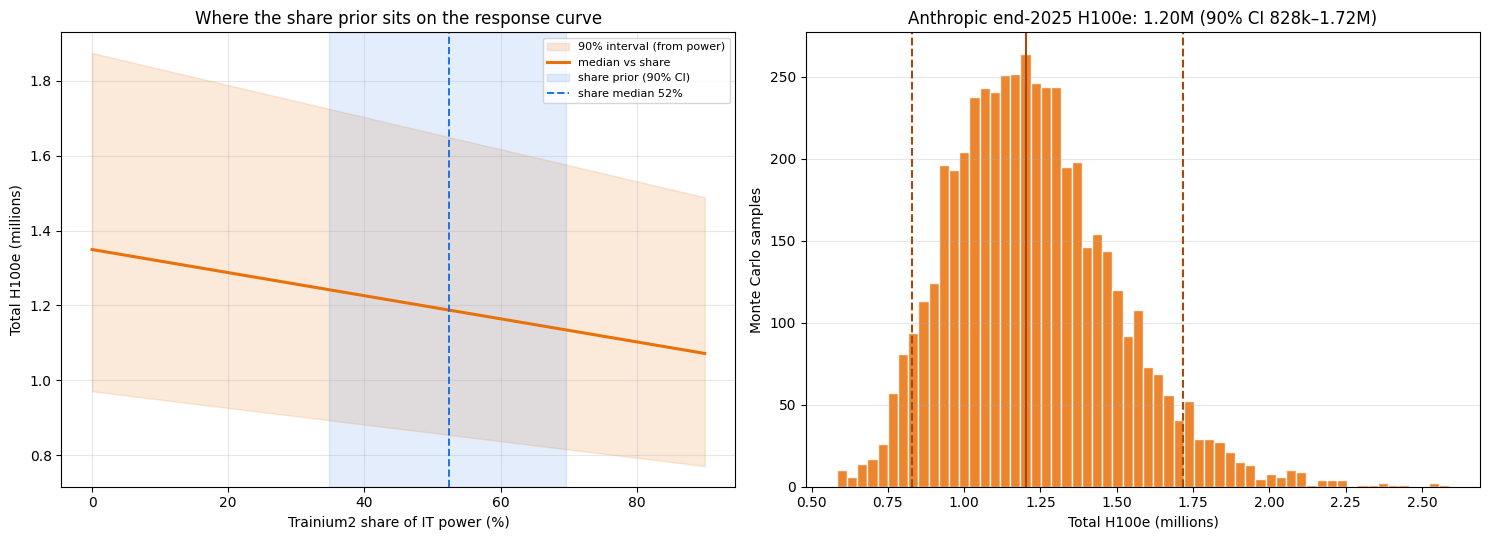

In [10]:
fig, (ax_curve, ax_hist) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: the response curve (median H100e vs share, with the power band), and the
# share prior's 90% CI shaded over it.
share_grid = np.round(np.arange(0.0, 0.901, 0.05), 2)
median_curve = np.array([np.median(anthropic_h100e(power_samples_mw, s)) for s in share_grid]) / 1e6
low_curve = np.array([percentiles(anthropic_h100e(power_samples_mw, s))[0] for s in share_grid]) / 1e6
high_curve = np.array([percentiles(anthropic_h100e(power_samples_mw, s))[2] for s in share_grid]) / 1e6

ax_curve.fill_between(share_grid * 100, low_curve, high_curve, color='#e8710a', alpha=0.15,
                      label='90% interval (from power)')
ax_curve.plot(share_grid * 100, median_curve, color='#e8710a', lw=2.2, label='median vs share')
ax_curve.axvspan(s_lo * 100, s_hi * 100, color='#1a73e8', alpha=0.12, label='share prior (90% CI)')
ax_curve.axvline(s_mid * 100, color='#1a73e8', ls='--', lw=1.4, label=f'share median {s_mid:.0%}')
ax_curve.set_title('Where the share prior sits on the response curve', fontsize=12)
ax_curve.set_xlabel('Trainium2 share of IT power (%)')
ax_curve.set_ylabel('Total H100e (millions)')
ax_curve.legend(loc='upper right', fontsize=8)
ax_curve.grid(True, alpha=0.3)

# Right: the headline H100e distribution (power and share combined).
ax_hist.hist(anthropic_h100e_samples / 1e6, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, style in zip((h_lo, h_mid, h_hi), ['--', '-', '--']):
    ax_hist.axvline(value / 1e6, color='#a8480a', ls=style, lw=1.5)
ax_hist.set_title(f'Anthropic end-2025 H100e: {fmt(h_mid)} (90% CI {fmt(h_lo)}–{fmt(h_hi)})', fontsize=12)
ax_hist.set_xlabel('Total H100e (millions)')
ax_hist.set_ylabel('Monte Carlo samples')
ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Cross-check: implied Trainium2 chip count

The share prior implies a Trainium2 chip count (Trainium2 power ÷ its IT watts).
It should land on the site evidence: ~720k chips at New Carlisle (626 MW at
~871 W), ~1.05M adding Madison (~910 MW combined), and below Amazon's ~1.4M
total as a hard ceiling.

Implied Anthropic Trainium2 chips (5th / median / 95th): 498k / 826k / 1.27M
   median is 59% of Amazon's 1.4M total; 2.1% of samples exceed the 1.4M ceiling
   New Carlisle anchor ~720k; + Madison ~1.05M


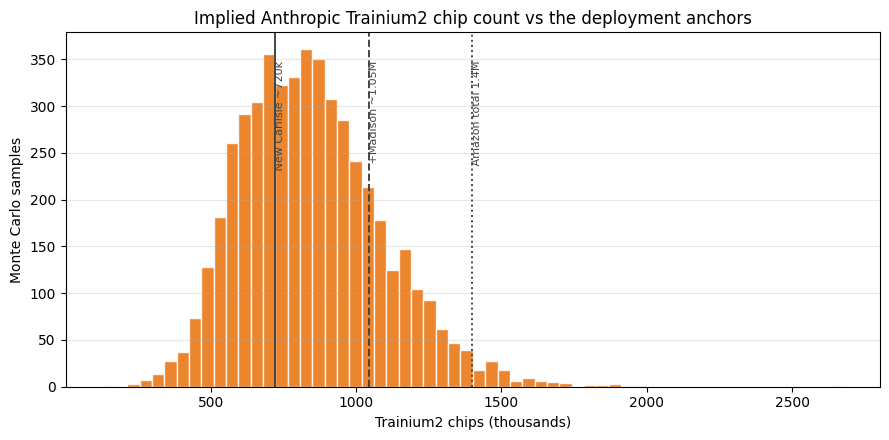

In [11]:
implied_trainium_chips = trainium_share * power_samples_mw * 1e6 / TRAINIUM2_IT_WATTS
c_lo, c_mid, c_hi = percentiles(implied_trainium_chips)
print(f'Implied Anthropic Trainium2 chips (5th / median / 95th): '
      f'{fmt(c_lo)} / {fmt(c_mid)} / {fmt(c_hi)}')
print(f'   median is {c_mid / 1.4e6:.0%} of Amazon\'s 1.4M total; '
      f'{np.mean(implied_trainium_chips > 1.4e6):.1%} of samples exceed the 1.4M ceiling')
print(f'   New Carlisle anchor ~720k; + Madison ~1.05M')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(implied_trainium_chips / 1e3, bins=60, color='#e8710a', alpha=0.85, edgecolor='white')
for value, label, style in [(720, 'New Carlisle ~720k', '-'), (1045, '+Madison ~1.05M', '--'),
                            (1400, 'Amazon total 1.4M', ':')]:
    ax.axvline(value, color='#444441', ls=style, lw=1.4)
    ax.text(value, ax.get_ylim()[1] * 0.92, f' {label}', rotation=90, va='top', fontsize=8, color='#444441')
ax.set_title('Implied Anthropic Trainium2 chip count vs the deployment anchors', fontsize=12)
ax.set_xlabel('Trainium2 chips (thousands)')
ax.set_ylabel('Monte Carlo samples')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. What drives the uncertainty

Turn each input on alone (the others held at their medians) to see how much of
the H100e spread it owns. The non-Trainium *composition* (Nvidia vs TPU) is left
out — §3 showed it barely moves the total — but the two buckets' sampled
efficiency multipliers get their own rows.

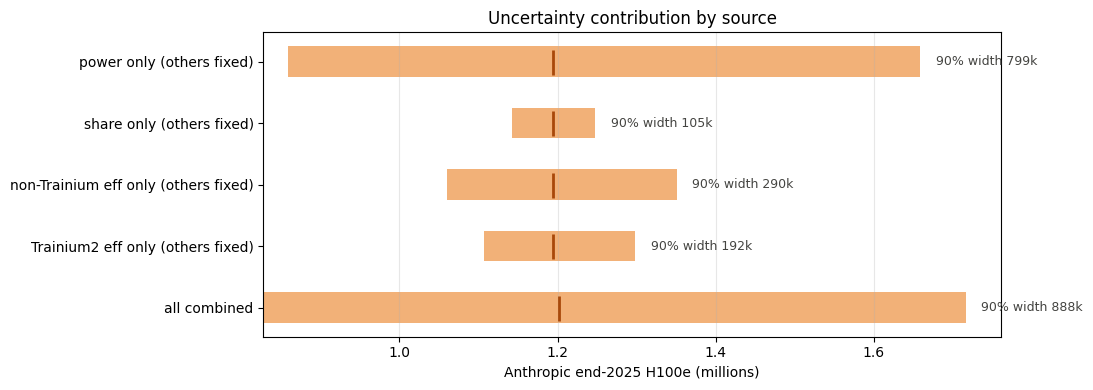

Anthropic end-2025 H100e by source (5th / median / 95th):
   power only (others fixed) : 859k / 1.19M / 1.66M
   share only (others fixed) : 1.14M / 1.19M / 1.25M
   non-Trainium eff only (others fixed): 1.06M / 1.19M / 1.35M
   Trainium2 eff only (others fixed): 1.11M / 1.19M / 1.30M
   all combined              : 828k / 1.20M / 1.72M


In [12]:
share_median = float(np.median(trainium_share))
power_median_mw = float(np.median(power_samples_mw))
eff_median = float(np.median(nontrainium_eff))

t_eff_median = float(np.median(trainium_eff))

decomposition = {
    'power only (others fixed)': anthropic_h100e(power_samples_mw, share_median, eff_median, t_eff_median),
    'share only (others fixed)': anthropic_h100e(power_median_mw, trainium_share, eff_median, t_eff_median),
    'non-Trainium eff only (others fixed)': anthropic_h100e(power_median_mw, share_median, nontrainium_eff, t_eff_median),
    'Trainium2 eff only (others fixed)': anthropic_h100e(power_median_mw, share_median, eff_median, trainium_eff),
    'all combined': anthropic_h100e_samples,
}

fig, ax = plt.subplots(figsize=(11, 4))
for row, (name, samples) in enumerate(decomposition.items()):
    lo, mid, hi = percentiles(samples)
    ax.barh(row, (hi - lo) / 1e6, left=lo / 1e6, color='#e8710a', alpha=0.55, height=0.5)
    ax.plot(mid / 1e6, row, marker='|', color='#a8480a', markersize=18, markeredgewidth=2)
    ax.text((hi + 20000) / 1e6, row, f'90% width {fmt(hi - lo)}', va='center', fontsize=9, color='#444441')
ax.set_yticks(range(len(decomposition)))
ax.set_yticklabels(list(decomposition))
ax.invert_yaxis()
ax.set_xlabel('Anthropic end-2025 H100e (millions)')
ax.set_title('Uncertainty contribution by source', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Anthropic end-2025 H100e by source (5th / median / 95th):')
for name, samples in decomposition.items():
    lo, mid, hi = percentiles(samples)
    print(f'   {name:26s}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}')

## 8. Sensitivity sweep: Trainium2 share from 10% to 90%

§5 put a prior on the Trainium2 share. Here we drop that prior and instead fix
the share at each value from 10% to 90%, with only the power draw still sampled
(both efficiency multipliers sit at their medians, ~1.0) —
an explicit answer to "how wrong could the headline be if the mix evidence is
wrong?"

The lever is shallow, because a watt of Trainium2 buys about 0.75× the H100e of
a non-Trainium watt: sliding the share across the whole 10–90% band moves the
median total far less than the power uncertainty does. The top of the band is
also physically implausible — at the median 1.4 GW, a very high share implies
more Trainium2 chips than Amazon's entire ~1.4M deployment ("fully
subscribed", and Anthropic is not the sole customer).

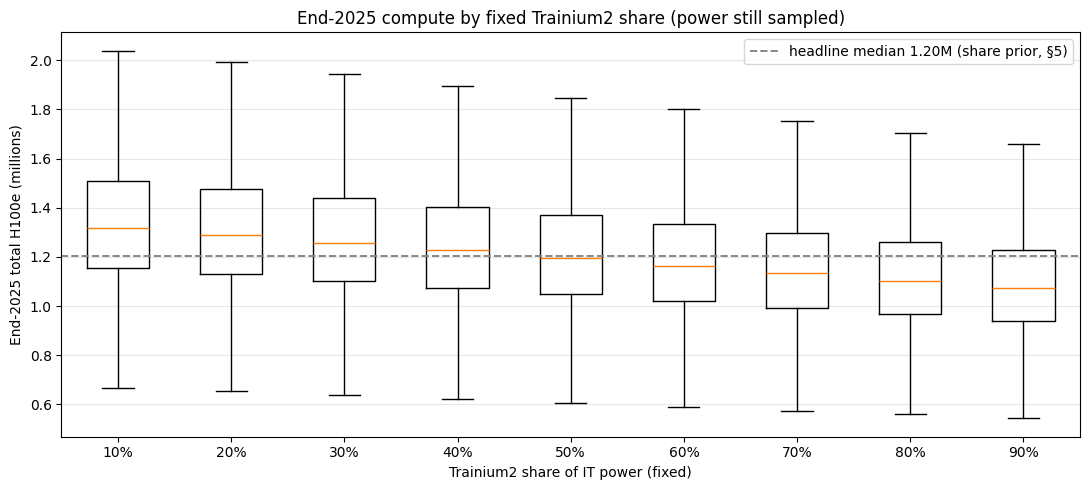

End-2025 H100e by fixed Trainium2 share (5th / median / 95th; median implied chips):
    10%: 949k / 1.32M / 1.83M   (~159k chips)
    20%: 927k / 1.29M / 1.79M   (~317k chips)
    30%: 904k / 1.26M / 1.75M   (~476k chips)
    40%: 882k / 1.23M / 1.70M   (~634k chips)
    50%: 860k / 1.20M / 1.66M   (~793k chips)
    60%: 838k / 1.16M / 1.62M   (~952k chips)
    70%: 816k / 1.13M / 1.57M   (~1.11M chips)
    80%: 793k / 1.10M / 1.53M   (~1.27M chips)
    90%: 771k / 1.07M / 1.49M   (~1.43M chips  — breaches Amazon's 1.4M-chip ceiling)

Full 10%→90% sweep moves the median from 1.32M (10% share) to 1.07M (90% share): +10% to -11% vs the headline median 1.20M


In [13]:
sweep_shares = np.round(np.arange(0.10, 0.901, 0.10), 2)
sweep_h100e = {share: anthropic_h100e(power_samples_mw, share) for share in sweep_shares}

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([sweep_h100e[share] / 1e6 for share in sweep_shares], showfliers=False, widths=0.55)
ax.set_xticks(range(1, len(sweep_shares) + 1))
ax.set_xticklabels([f'{share:.0%}' for share in sweep_shares])
ax.axhline(h_mid / 1e6, color='#888780', ls='--', lw=1.4,
           label=f'headline median {fmt(h_mid)} (share prior, §5)')
ax.set_xlabel('Trainium2 share of IT power (fixed)')
ax.set_ylabel('End-2025 total H100e (millions)')
ax.set_title('End-2025 compute by fixed Trainium2 share (power still sampled)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('End-2025 H100e by fixed Trainium2 share (5th / median / 95th; median implied chips):')
for share in sweep_shares:
    lo, mid, hi = percentiles(sweep_h100e[share])
    # Implied Trainium2 chip count at the median power draw, for the §6 ceiling check.
    implied_chips = share * float(np.median(power_samples_mw)) * 1e6 / TRAINIUM2_IT_WATTS
    ceiling_note = '  — breaches Amazon\'s 1.4M-chip ceiling' if implied_chips > 1.4e6 else ''
    print(f'   {share:>4.0%}: {fmt(lo)} / {fmt(mid)} / {fmt(hi)}   (~{fmt(implied_chips)} chips{ceiling_note})')

low_end_median = float(np.median(sweep_h100e[sweep_shares[0]]))
high_end_median = float(np.median(sweep_h100e[sweep_shares[-1]]))
headline_median = float(np.median(anthropic_h100e_samples))
print(f'\nFull 10%→90% sweep moves the median from {fmt(low_end_median)} (10% share) to '
      f'{fmt(high_end_median)} (90% share): {low_end_median / headline_median - 1:+.0%} to '
      f'{high_end_median / headline_median - 1:+.0%} vs the headline median {fmt(headline_median)}')

## 9. Takeaways

- **Headline: Anthropic had roughly 1.2M H100e online at end-2025**, with a 90%
  interval of about **0.84M–1.72M** — centered in the research summary's "≥1M,
  likely <1.5M" range, with tails poking past it on both sides after the 7/30
  power-prior widening and the 8/4 efficiency multipliers; ~68% of OpenAI's ~1.74M.
- **The estimate rests on four inputs: total power, the Trainium2 share, and the
  two bucket-efficiency multipliers (non-Trainium 0.8–1.25, Trainium2 0.85–1.2,
  §3).** The
  share prior (median ~52%, 90% CI 35–70%) is anchored on the site power in
  Epoch's data-center directory — New Carlisle ~626 MW at end-2025 plus Madison
  ~284 MW, with allowances for timing and non-Anthropic use (§5). It implies
  ~845k Anthropic Trainium2 chips at the median, between the New Carlisle-only
  (~720k) and +Madison (~1.05M) anchors, with ~1% of draws breaching Amazon's
  1.4M-chip ceiling.
- **Power is the larger source of spread** — its 1.0–1.9 GW band moves H100e
  several times as much as the share prior does, and even pinning the share
  anywhere from 10% to 90% (§8) only moves the median about ±10%. Tightening the
  power figure is the highest-leverage way to narrow the estimate.
- **Nvidia and TPU are interchangeable here** — within a few percent on H100e per
  watt (native-peak basis), so the non-Trainium *split* does not affect the total.
  Each bucket's overall efficiency level is still uncertain, though: the sampled
  multipliers together are the second-largest source of spread (§7) — ahead of
  the share, well behind power. Trainium2's point value in particular rests on an
  estimated ~500 W TDP times an Nvidia-derived 1.74× overhead (§3).